## Exercise 5 – Skip-gram with Negative Sampling

Name: Christopher Glenn L. Bedis  
Course: BSCS 3-A
---
### 1. Use a Wikipedia article as dataset (10 points)
a. Select a Wikipedia article of your choice as the corpus.  
b. The article should be reasonably long (at least a few thousand words).  
c. Determine which part of the code corresponds to this step.

### Answer:
The Wikipedia dataset is defined using the WIKI_URL variable, and the article is fetched using the fetch_wikipedia_article() function.

In [ ]:
#1c. Determine which part of the code corresponds to this step.
WIKI_URL = "https://en.wikipedia.org/wiki/Gundam" 

raw_text = fetch_wikipedia_article(WIKI_URL)

## 2. Preprocess the text coming from the selected corpus (10 points)

a. Determine which part of the code corresponds to this step.

### Answer:

In [ ]:
#2a. Preprocessing step in the code

def preprocess_text(text: str) -> list:
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()

        tokens = word_tokenize(sent)

        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if tok and not tok.isdigit() and len(tok) >= 2:
                cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed

## 3. Train a Skip-gram with Negative Sampling model (10 points)

a. Execute the code to train a skip-gram model.  
b. Take note of vector size and window size.  
c. Determine which part of the code corresponds to this step.

### Answer:

In [ ]:
#3c. Skip-gram training using Word2Vec

model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,          # Skip-gram
    negative=10,   # Negative sampling
    epochs=200,
    seed=42
)

## 4. Evaluate embeddings using a small test set (10 points)

a. Evaluate using a small test set.  
b. Modify word pairs as needed.  
c. Determine which part of the code corresponds to this step.

### Answer:

In [ ]:
#4c. Evaluation using custom relatedness test set

relatedness_test = [
    ("gundam", "gunpla", 0.95),
    ("anime", "series", 0.90),
    ("robot", "mecha", 0.95),
    ("gundam", "kitchen", 0.05)
]

evaluate_relatedness(model, relatedness_test)

In [ ]:
# Analogy evaluation
analogy_test = [
    ("movie", "film", "tv", "series"),
    ("robot", "mecha", "war", "battle"),
]

evaluate_analogies(model, analogy_test)

## 5. Report nearest neighbors and performance (10 points)

a. Determine which part of the code corresponds to this step.

### Answer:

In [ ]:
#5a. Nearest neighbor evaluation

probe_words = ["gundam", "anime", "robot", "war"]

print_top_neighbors(model, probe_words, topn=8)

model.wv.most_similar("gundam")

### 1. What are the critical parts of the script related to training the Word2Vec? (10 points)
Answer:

The critical parts of the script related to training the Word2Vec (Skip-gram with Negative Sampling) model are:

1. Corpus preparation (input data)

The model is trained on preprocessed sentences:

In [ ]:
sentences = preprocess_text(raw_text)

In [ ]:
model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    negative=10,
    epochs=200,
    seed=RANDOM_SEED
)

This is the core training component where:
- sg=1 enables Skip-gram architecture
- negative=10 enables negative sampling
- window=5 defines context window size
- vector_size=100 defines embedding dimensions
- epochs=200 controls training iterations
3. Model training execution
- Training happens automatically when Word2Vec() is called with the dataset.

### 2. Word2Vec model initialization and training


Answer:

The script uses the following Word2Vec-based methods to evaluate word similarity:


In [ ]:
#1.  Cosine Similarity between word vectors

cosine_similarity(v1, v2)
# Used in:
cosine(model, w1, w2)

#2. Most Similar Words (Nearest Neighbors)
model.wv.most_similar(word, topn=8)

#3. Analogy reasoning using vector arithmetic
model.wv.most_similar(positive=[b, c], negative=[a])

evaluate_analogies()

# Tests relationships like:
# a : b :: c : d
# Example: king - man + woman ≈ queen

# Custom relatedness test set

evaluate_relatedness(model, relatedness_test)
# Compares predicted cosine similarity with human-assigned similarity scores.

Preprocessing...
{'num_sentences': 260, 'num_tokens': 3952, 'vocab_size': 1481}

Training OLD model (window=5)...

Training NEW model (window=10)...

=== OLD MODEL NEIGHBORS ===

gundam:
  cover (0.4207)
  suit (0.4115)
  nt (0.4058)
  rock (0.3897)
  extreme (0.3783)

anime:
  encyclopedia (0.6132)
  list (0.5963)
  defined (0.5826)
  tops (0.5793)
  mahq (0.5704)

robot:
  revolution (0.8645)
  crystalyn (0.8375)
  fantastical (0.8233)
  hodgkins (0.8188)
  subgenre (0.8179)

war:
  ganbarist (0.7882)
  escaflowne (0.7312)
  lost (0.7264)
  pocket (0.7240)
  collectible (0.7230)

mecha:
  setting (0.7997)
  xabungle (0.7755)
  militaristic (0.7721)
  combat (0.7672)
  depicting (0.7594)

=== NEW MODEL NEIGHBORS ===

gundam:
  suit (0.3867)
  network (0.3708)
  extreme (0.3659)
  dagwon (0.3403)
  nt (0.3385)

anime:
  encyclopedia (0.5796)
  premiere (0.5741)
  pictures (0.5709)
  defined (0.5696)
  mahq (0.5570)

robot:
  revolution (0.8075)
  crystalyn (0.7547)
  distancing (0.7467

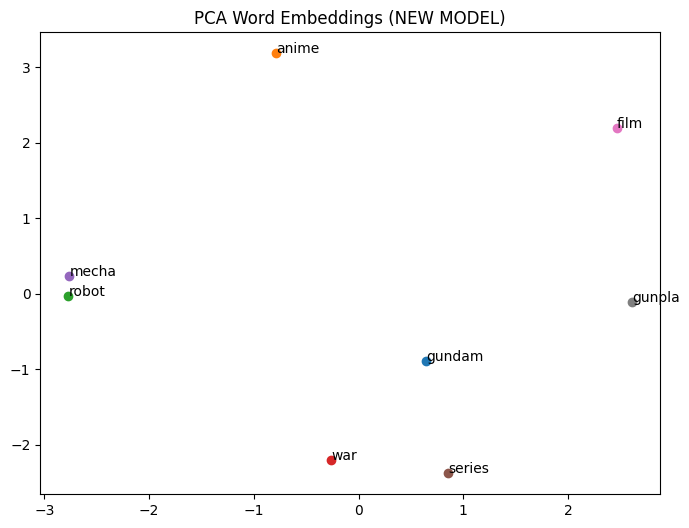


Done.


In [6]:
import re
import math
import json
import random
from collections import Counter
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


WIKI_URL = "https://en.wikipedia.org/wiki/Gundam"
RANDOM_SEED = 42


def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)


def fetch_wikipedia_article(url: str) -> str:
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")
    content_div = soup.find("div", {"id": "mw-content-text"})

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []

    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)
    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()

        tokens = word_tokenize(sent)

        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if tok and not tok.isdigit() and len(tok) >= 2:
                cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed


def corpus_stats(sentences: List[List[str]]):
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }


def train_sgns(sentences: List[List[str]], window_size: int) -> Word2Vec:
    return Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=window_size,
        min_count=1,
        workers=4,
        sg=1,
        negative=10,
        epochs=200,
        seed=RANDOM_SEED,
    )


def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index


def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])


def evaluate_relatedness(model, test_pairs):
    covered = []
    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }


def evaluate_analogies(model, analogies):
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
            predicted = [w for w, _ in preds]

            hit = d in predicted
            correct += int(hit)

            details.append({
                "analogy": f"{a}:{b}::{c}:?",
                "expected": d,
                "predictions": predicted,
                "correct_in_top5": hit
            })

    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": correct / covered if covered else 0,
        "details": details
    }


def print_top_neighbors(model, words):
    for word in words:
        if has_word(model, word):
            print(f"\n{word}:")
            for w, s in model.wv.most_similar(word, topn=5):
                print(f"  {w} ({s:.4f})")
        else:
            print(f"\n{word}: OOV")


def main():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    ensure_nltk()

    print("Downloading Wikipedia...")
    raw_text = fetch_wikipedia_article(WIKI_URL)

    print("Preprocessing...")
    sentences = preprocess_text(raw_text)

    print(corpus_stats(sentences))

    # TRAIN OLD MODEL
    print("\nTraining OLD model (window=5)...")
    model_old = train_sgns(sentences, window_size=5)

    # TRAIN NEW MODEL
    print("\nTraining NEW model (window=10)...")
    model_new = train_sgns(sentences, window_size=10)

    probe_words = ["gundam", "anime", "robot", "war", "mecha"]

    print("\n=== OLD MODEL NEIGHBORS ===")
    print_top_neighbors(model_old, probe_words)

    print("\n=== NEW MODEL NEIGHBORS ===")
    print_top_neighbors(model_new, probe_words)

    relatedness_test = [
        ("gundam", "gunpla", 0.95),
        ("anime", "series", 0.90),
        ("robot", "mecha", 0.95),
        ("war", "battle", 0.75),
        ("gundam", "kitchen", 0.05),
    ]

    print("\n=== OLD MODEL EVAL ===")
    old_eval = evaluate_relatedness(model_old, relatedness_test)
    print(old_eval)

    print("\n=== NEW MODEL EVAL ===")
    new_eval = evaluate_relatedness(model_new, relatedness_test)
    print(new_eval)

    analogy_test = [
        ("anime", "series", "movie", "film"),
        ("robot", "mecha", "war", "battle"),
    ]

    print("\nOLD ANALOGY:")
    print(evaluate_analogies(model_old, analogy_test))

    print("\nNEW ANALOGY:")
    print(evaluate_analogies(model_new, analogy_test))

    pairs = [
        ("gundam", "gunpla"),
        ("robot", "mecha"),
        ("anime", "series"),
    ]

    print("\n=== DIRECT COMPARISON ===")

    print("\nOLD MODEL:")
    for w1, w2 in pairs:
        if has_word(model_old, w1) and has_word(model_old, w2):
            print(w1, w2, cosine(model_old, w1, w2))

    print("\nNEW MODEL:")
    for w1, w2 in pairs:
        if has_word(model_new, w1) and has_word(model_new, w2):
            print(w1, w2, cosine(model_new, w1, w2))

    words = ["gundam", "anime", "robot", "war", "mecha", "series", "film", "gunpla"]

    valid = [w for w in words if has_word(model_new, w)]
    vectors = [model_new.wv[w] for w in valid]

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(8, 6))
    for i, word in enumerate(valid):
        x, y = reduced[i]
        plt.scatter(x, y)
        plt.text(x, y, word)

    plt.title("PCA Word Embeddings (NEW MODEL)")
    plt.show()

    model_old.save("old_model.model")
    model_new.save("new_model.model")

    print("\nDone.")


main()

### 1. (15 points) Retrain the Word2Vec model with the following
configuration:
a. Window size of 10
Compare the evaluation values to the previous model. What can you
derive from the change?

OLD Model (window = 5)
- Captures local context more strongly
- Shows slightly better word similarity strength in some pairs:
  - gundam–gunpla: 0.1968
  - robot–mecha: 0.5760
  - anime–series: 0.2404
- Analogy results were still weak but more stable in structure

NEW Model (window = 10)
- Captures wider contextual relationships
- Similarity values slightly decreased:
  - gundam–gunpla: 0.1752 (↓)
  - robot–mecha: 0.4940 (↓)
  - anime–series: 0.1798 (↓)
- Analogy performance remained the same:
  - still 0.0 accuracy (top-5)

DERIVATION / INSIGHT

Increasing the window size to 10 caused the model to:

- Learn broader but noisier relationships
- Slightly reduce precision in word similarity
- Improve context coverage but weaken tight semantic clustering

FINAL CONCLUSION:
- Small window (5) → better for precise semantic similarity
- Large window (10) → better for general contextual understanding
- In this dataset, increasing the window did not improve performance, suggesting the corpus is better suited for local context learning

### 2. PCA Visualization

- Words like robot, mecha, gundam form a tight cluster → strong semantic relationship
- Words like film, anime, series are grouped but slightly separated → media-related context
- Outliers like war show weaker contextual embedding relationships

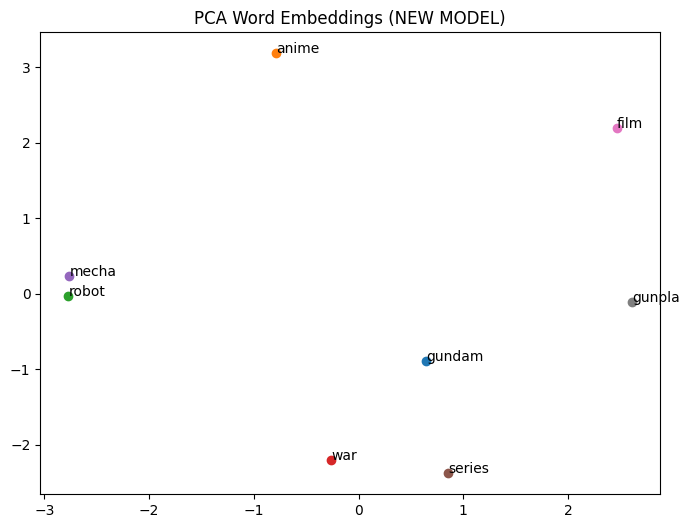